In [15]:
from ultralytics import YOLO

model = YOLO('../weights/hazard/yolo26s.pt')

results = model('../dataset/images/photo4.jpg')

print(results[0])


image 1/1 /Users/egormuhaev/Documents/Проекты/monitoring-construction-site/notebooks/../dataset/images/photo4.jpg: 384x640 2 machinerys, 3 vehicles, 79.9ms
Speed: 5.1ms preprocess, 79.9ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)
ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
depth: None
keypoints: None
masks: None
names: {0: 'Hardhat', 1: 'Mask', 2: 'NO-Hardhat', 3: 'NO-Mask', 4: 'NO-Safety Vest', 5: 'Person', 6: 'Safety Cone', 7: 'Safety Vest', 8: 'machinery', 9: 'utility pole', 10: 'vehicle'}
obb: None
orig_img: array([[[195, 176, 168],
        [195, 176, 168],
        [195, 176, 168],
        ...,
        [224, 209, 206],
        [224, 209, 206],
        [224, 209, 206]],

       [[195, 176, 168],
        [195, 176, 168],
        [195, 176, 168],
        ...,
        [224, 209, 206],
        [224, 209, 206],
        [224, 209, 206]],

       [[196, 177, 169],
        [196, 177, 169],
        [196, 1

/Users/egormuhaev/Documents/Проекты/monitoring-construction-site/.venv/lib/python3.10/site-packages/yolov5/models/common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
image 1/1: 1106x1866 1 Grader
Speed: 72.9ms pre-process, 93.5ms inference, 19.8ms NMS per image at shape (1, 3, 384, 640)


classes: {0: 'Bull_dozer', 1: 'Dumb_truck', 2: 'Excavator', 3: 'Grader', 4: 'Loader', 5: 'Mobile_crane', 6: 'Reflective vest', 7: 'Roller', 8: 'Safety helmet', 9: 'Worker'}
        xmin        ymin         xmax        ymax  confidence  class    name
0  50.161865  196.191666  1860.986938  945.216614    0.614729      3  Grader


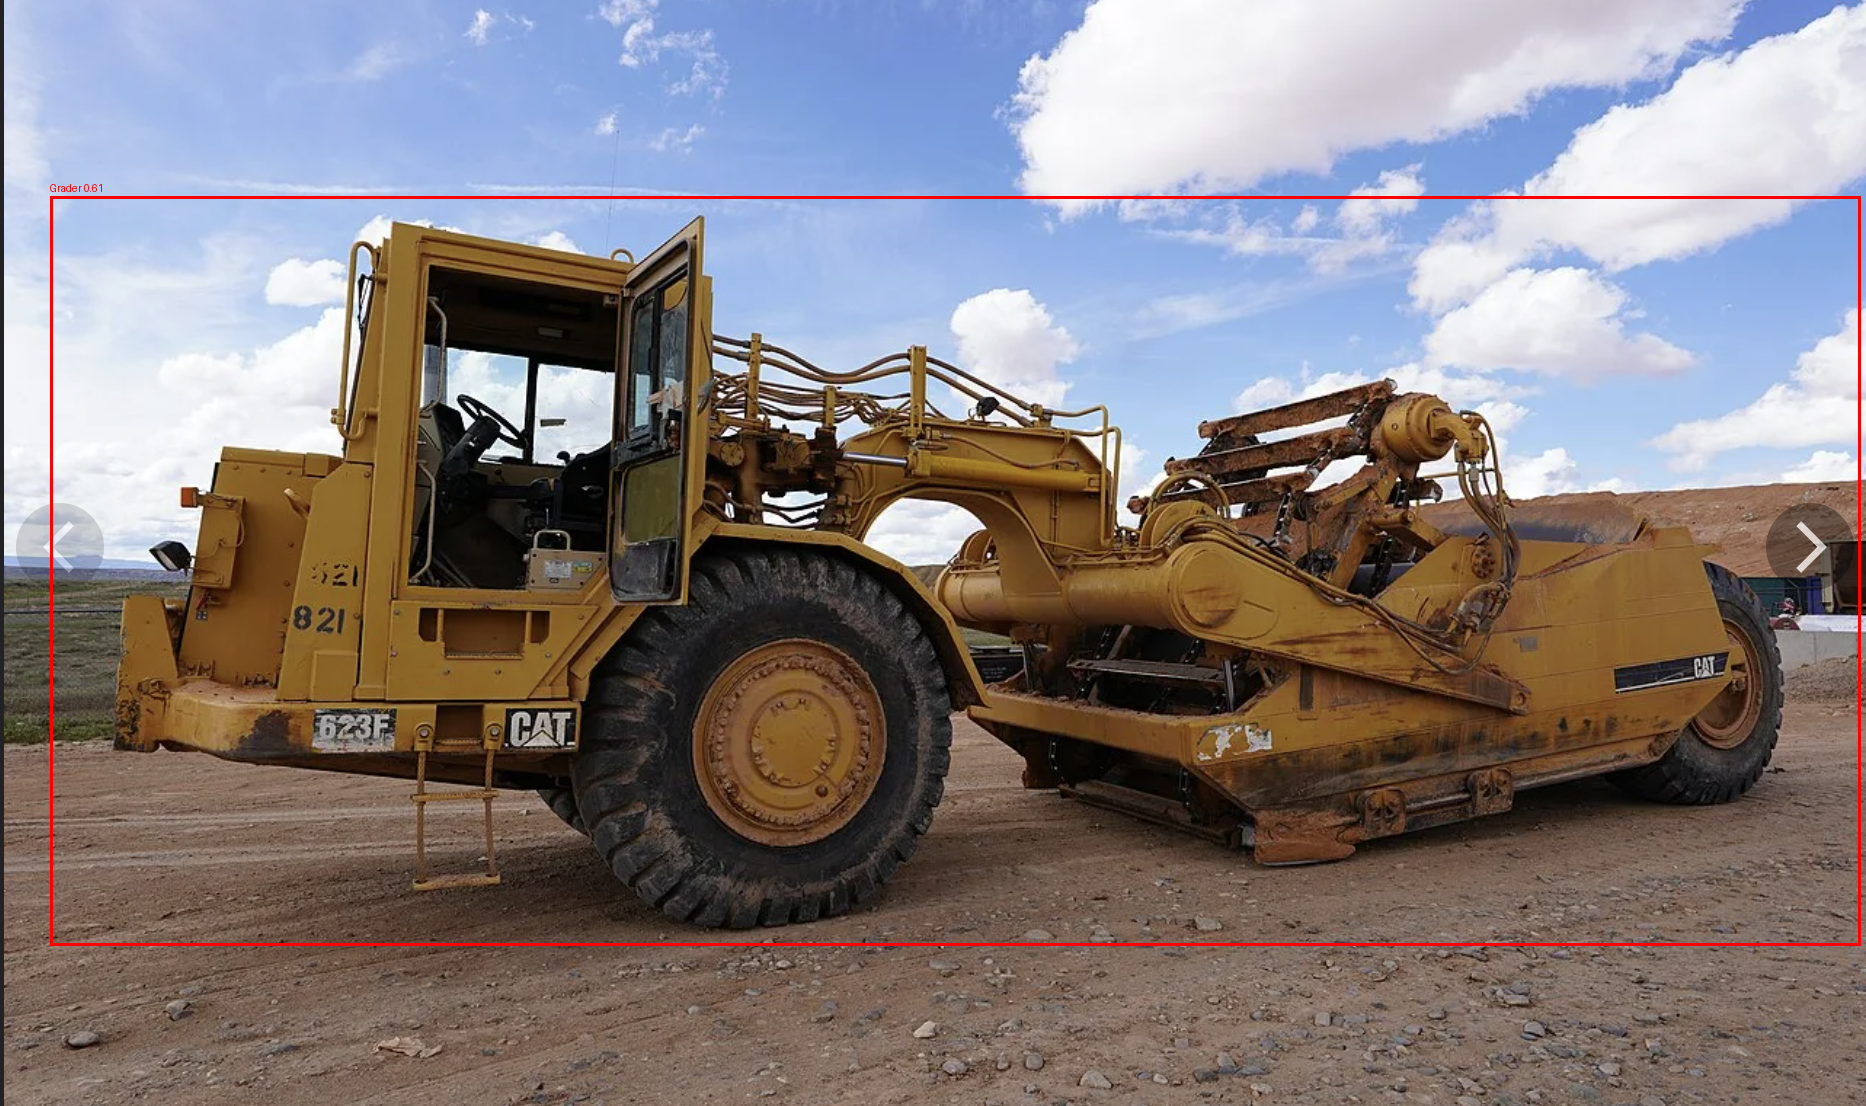

In [13]:
import sys
from pathlib import Path
from types import ModuleType

try:
    import pkg_resources
except ModuleNotFoundError:
    from packaging.version import parse as parse_version

    pkg_resources = ModuleType('pkg_resources')
    pkg_resources.parse_version = parse_version
    sys.modules['pkg_resources'] = pkg_resources

from huggingface_hub.errors import RepositoryNotFoundError

if 'huggingface_hub.utils._errors' not in sys.modules:
    _errors = ModuleType('huggingface_hub.utils._errors')
    _errors.RepositoryNotFoundError = RepositoryNotFoundError
    sys.modules['huggingface_hub.utils._errors'] = _errors

import torch
import torch.serialization as _torch_serialization

# YOLOv5 checkpoints need pickle. Always wrap the real torch.serialization.load,
# so a previous recursive monkey-patch (from re-running this cell) is replaced.
if not getattr(torch.load, '_yolov5_weights_only_patch', False):
    def _torch_load(*args, _orig=_torch_serialization.load, **kwargs):
        kwargs.setdefault('weights_only', False)
        return _orig(*args, **kwargs)

    _torch_load._yolov5_weights_only_patch = True
    torch.load = _torch_load

import yolov5

_yolov5_root = str(Path(yolov5.__file__).resolve().parent)
if _yolov5_root not in sys.path:
    sys.path.insert(0, _yolov5_root)

from IPython.display import display
from PIL import Image, ImageDraw

model = yolov5.load('uisikdag/yolo-v5-construction-machine-detection')
model.conf = 0.25
model.iou = 0.45

image_path = '../dataset/images/photo7.png'
results = model(image_path, size=640)
results.print()

detections = results.pandas().xyxy[0]
print('classes:', model.names)
print(detections)

image = Image.open(image_path).convert('RGB')
draw = ImageDraw.Draw(image)
for row in detections.itertuples():
    draw.rectangle([row.xmin, row.ymin, row.xmax, row.ymax], outline='red', width=3)
    draw.text((row.xmin, max(row.ymin - 14, 0)), f'{row.name} {row.confidence:.2f}', fill='red')

display(image)

In [18]:
model = YOLO('../weights/construction-vehicle/best.pt')

results = model('../dataset/images/photo4.jpg')

print(results[0])


image 1/1 /Users/egormuhaev/Documents/Проекты/monitoring-construction-site/notebooks/../dataset/images/photo4.jpg: 384x640 2 machinerys, 6 vehicles, 351.1ms
Speed: 10.9ms preprocess, 351.1ms inference, 19.7ms postprocess per image at shape (1, 3, 384, 640)
ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
depth: None
keypoints: None
masks: None
names: {0: 'Hardhat', 1: 'Mask', 2: 'NO-Hardhat', 3: 'NO-Mask', 4: 'NO-Safety Vest', 5: 'Person', 6: 'Safety Cone', 7: 'Safety Vest', 8: 'machinery', 9: 'vehicle'}
obb: None
orig_img: array([[[195, 176, 168],
        [195, 176, 168],
        [195, 176, 168],
        ...,
        [224, 209, 206],
        [224, 209, 206],
        [224, 209, 206]],

       [[195, 176, 168],
        [195, 176, 168],
        [195, 176, 168],
        ...,
        [224, 209, 206],
        [224, 209, 206],
        [224, 209, 206]],

       [[196, 177, 169],
        [196, 177, 169],
        [196, 177, 169],
      

In [33]:
import torch
from sentence_transformers import SentenceTransformer

classes = [
    "crawler excavator", "wheeled excavator", "mini excavator",
    "bulldozer", "wheel loader", "backhoe loader", "skid steer loader",
    "telescopic handler", "tower crane", "mobile crane", "crawler crane",
    "dump truck", "concrete mixer truck", "motor grader", "road roller",
    "asphalt paver", "compactor", "forklift", "scraper"
]

st = SentenceTransformer('sentence-transformers/clip-ViT-B-32')
emb = st.encode(classes, normalize_embeddings=True, convert_to_tensor=True)

model = YOLO("../weights/yolo-world/yolov8x-worldv2.pt") 
model.model.txt_feats = emb.unsqueeze(0)
model.model.model[-1].nc = len(classes)
model.model.names = classes

if getattr(model, "predictor", None):
    model.predictor.model.names = classes

results = model.predict("../dataset/images/photo7.png", conf=0.25)

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 1730.44it/s]



image 1/1 /Users/egormuhaev/Documents/Проекты/monitoring-construction-site/notebooks/../dataset/images/photo7.png: 384x640 1 crawler excavator, 4011.7ms
Speed: 68.6ms preprocess, 4011.7ms inference, 360.6ms postprocess per image at shape (1, 3, 384, 640)


In [34]:
import cv2
annotated_image = results[0].plot()

cv2.imwrite('my_result_image.jpg', annotated_image)

True